# 04 — Naive Bayes Classifier: Task Category Prediction

**Owner:** Sanjay
**Objective:** Train a Multinomial Naive Bayes classifier on TF-IDF features to predict `category` from task text.

**Scope of this notebook:**
- Build TF-IDF features (unigram vs. bigram) from `task_description` (+ `priority`/`status` as extra text signal)
- Tune the Laplace smoothing parameter `alpha` via cross-validated grid search
- Evaluate with accuracy, per-class & macro precision/recall/F1 — with special attention to the small `Research` class
- Confusion matrix heatmap + written observations on which categories get confused

> **Note on data:** This notebook currently runs on a 30-row sample dataset (`tasks_sample.csv`) provided during development. It is written so that swapping in the full dataset only requires changing the `DATA_PATH` variable in the cell below — no other code changes needed, as long as the column names (`task_description`, `category`, `priority`, `status`) match.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 100)

# ---- CHANGE THIS to the full dataset path once available ----
DATA_PATH = "tasks_sample.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (30, 13)


,task_id,task_description,category,priority,status,created_date,due_date,estimated_hours,story_points,assignee_id,assignee_experience_years,assignee_open_tasks,days_to_deadline
0,TASK-12157,Implement pagination and lazy loading for the landing page,Feature,Low,Open,2026-05-13,2026-05-31,9.9,3.0,USER-06,2.8,5,18
1,TASK-10453,Correct the wrong currency formatting shown on the login page,Bug Fix,Critical,Open,2026-05-24,2026-05-28,7.1,2.0,USER-12,14.6,4,4
2,TASK-12716,Add role-based access control to the database layer,Feature,Medium,Open,2026-04-09,2026-05-09,12.8,3.0,USER-24,5.8,14,30
3,TASK-16240,Implement pagination and lazy loading for the email scheduler,Feature,Low,Open,2026-02-14,2026-03-07,4.1,1.0,USER-14,3.6,18,21
4,TASK-15364,Write unit tests covering edge cases of the authentication service,Testing,Low,In Progress,2026-03-16,2026-03-25,2.1,8.0,USER-04,9.2,20,9


## 1. Explore the target class distribution

Naive Bayes (and macro-averaged metrics) are sensitive to class imbalance. We check the distribution up front — this is where we confirm `Research` is a minority class worth watching closely.

category
Feature          10
Testing           7
Bug Fix           6
Maintenance       2
Research          2
Documentation     2
Deployment        1
Name: count, dtype: int64


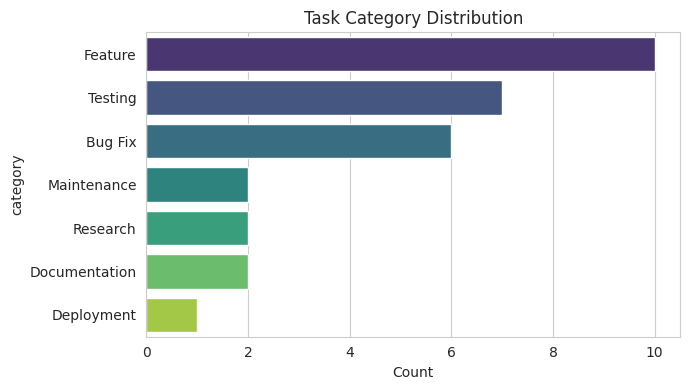


Smallest class: 'Deployment' with 1 samples (3.3% of data)


In [2]:
class_counts = df["category"].value_counts()
print(class_counts)

plt.figure(figsize=(7,4))
sns.barplot(x=class_counts.values, y=class_counts.index, hue=class_counts.index,
            palette="viridis", legend=False)
plt.xlabel("Count")
plt.title("Task Category Distribution")
plt.tight_layout()
plt.show()

min_class = class_counts.idxmin()
print(f"\nSmallest class: '{min_class}' with {class_counts.min()} samples "
      f"({class_counts.min()/len(df):.1%} of data)")

> **Sample-data caveat:** With only 30 rows and 7 classes, several classes (`Research`, `Documentation`, `Maintenance`, `Deployment`) have 1–2 examples. This is too few to reliably stratify into train/test splits or run 5-fold CV. The code below uses safeguards (reduced CV folds, warnings) that will no longer be necessary once the full dataset is loaded — but the *pipeline logic* is what matters and carries over unchanged.

## 2. Build the text field and train/test split

Per project decision, the text fed into TF-IDF combines `task_description` with `priority` and `status`, since these can carry category-relevant signal (e.g., "Critical" bugs vs. "Low" priority research tasks).

In [3]:
df["text"] = (
    df["task_description"].astype(str) + " " +
    df["priority"].astype(str) + " " +
    df["status"].astype(str)
)

X = df["text"]
y = df["category"]

# Guard: stratified split needs every class to have >= 2 members.
class_counts = y.value_counts()
can_stratify = (class_counts.min() >= 2)

if can_stratify:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
else:
    print("WARNING: at least one class has <2 members — stratified split not possible. "
          "Falling back to a plain random split (will not be an issue on the full dataset).")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print("\nTrain class counts:\n", y_train.value_counts())
print("\nTest class counts:\n", y_test.value_counts())

Train size: 22, Test size: 8

Train class counts:
 category
Feature          8
Testing          5
Bug Fix          4
Maintenance      2
Deployment       1
Documentation    1
Research         1
Name: count, dtype: int64

Test class counts:
 category
Feature          2
Testing          2
Bug Fix          2
Research         1
Documentation    1
Name: count, dtype: int64


## 3. TF-IDF vectorization: unigram vs. bigram

We build two feature sets so we can directly compare whether adding bigrams (two-word phrases like "load testing" or "role based") improves separability between categories.

In [4]:
tfidf_uni = TfidfVectorizer(ngram_range=(1, 1), min_df=1, stop_words="english")
tfidf_bi  = TfidfVectorizer(ngram_range=(1, 2), min_df=1, stop_words="english")

Xtr_uni = tfidf_uni.fit_transform(X_train)
Xte_uni = tfidf_uni.transform(X_test)

Xtr_bi = tfidf_bi.fit_transform(X_train)
Xte_bi = tfidf_bi.transform(X_test)

print(f"Unigram vocab size: {len(tfidf_uni.vocabulary_)}")
print(f"Bigram (uni+bi) vocab size: {len(tfidf_bi.vocabulary_)}")

Unigram vocab size: 95
Bigram (uni+bi) vocab size: 221


> **min_df note:** on the full dataset, raise `min_df` to 2–3 to drop rare noisy terms and keep the vocabulary generalizable. It's set to 1 here only because the sample is too small otherwise.

## 4. Tune alpha with GridSearchCV (scored on macro-F1)

We deliberately score the grid search on **macro-F1**, not accuracy. Accuracy would let the model ignore the small `Research` class entirely and still look good, since it's outnumbered by classes like `Feature`. Macro-F1 weights every class equally regardless of size.

In [5]:
alpha_grid = {"alpha": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]}

# CV folds can't exceed the smallest class count in y_train
n_splits = max(2, min(5, y_train.value_counts().min()))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42) if y_train.value_counts().min() >= 2 else n_splits

def tune_alpha(Xtr, name):
    grid = GridSearchCV(
        MultinomialNB(), alpha_grid, scoring="f1_macro", cv=cv, error_score="raise"
    )
    grid.fit(Xtr, y_train)
    print(f"[{name}] best alpha = {grid.best_params_['alpha']}  "
          f"(CV macro-F1 = {grid.best_score_:.3f})")
    return grid

try:
    grid_uni = tune_alpha(Xtr_uni, "Unigram")
    grid_bi  = tune_alpha(Xtr_bi, "Bigram")
except ValueError as e:
    print("Grid search failed — most likely because the sample dataset is too small "
          "for cross-validation with this many classes.")
    print(f"Details: {e}")
    raise

[Unigram] best alpha = 0.5  (CV macro-F1 = 0.231)
[Bigram] best alpha = 0.1  (CV macro-F1 = 0.247)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


## 5. Evaluate both feature sets on the held-out test set

Per-class precision/recall/F1 plus macro averages — macro is the number to watch for `Research`.

In [6]:
def evaluate(name, model, Xte):
    preds = model.predict(Xte)
    acc = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    print(f"\n=== {name} (alpha={model.alpha}) ===")
    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_test, preds, digits=3, zero_division=0))
    return preds, report, acc

preds_uni, report_uni, acc_uni = evaluate("Unigram", grid_uni.best_estimator_, Xte_uni)
preds_bi,  report_bi,  acc_bi  = evaluate("Bigram",  grid_bi.best_estimator_,  Xte_bi)


=== Unigram (alpha=0.5) ===
Accuracy: 0.625
               precision    recall  f1-score   support

      Bug Fix      1.000     1.000     1.000         2
Documentation      0.000     0.000     0.000         1
      Feature      0.400     1.000     0.571         2
     Research      0.000     0.000     0.000         1
      Testing      1.000     0.500     0.667         2

     accuracy                          0.625         8
    macro avg      0.480     0.500     0.448         8
 weighted avg      0.600     0.625     0.560         8


=== Bigram (alpha=0.1) ===
Accuracy: 0.875


               precision    recall  f1-score   support

      Bug Fix      1.000     1.000     1.000         2
Documentation      1.000     1.000     1.000         1
      Feature      0.667     1.000     0.800         2
     Research      0.000     0.000     0.000         1
      Testing      1.000     1.000     1.000         2

     accuracy                          0.875         8
    macro avg      0.733     0.800     0.760         8
 weighted avg      0.792     0.875     0.825         8



## 6. Metrics comparison table

In [7]:
results = pd.DataFrame([
    {
        "Feature Set": "Unigram",
        "Best Alpha": grid_uni.best_estimator_.alpha,
        "Accuracy": acc_uni,
        "Macro Precision": report_uni["macro avg"]["precision"],
        "Macro Recall": report_uni["macro avg"]["recall"],
        "Macro F1": report_uni["macro avg"]["f1-score"],
        "Research Recall": report_uni.get("Research", {}).get("recall", np.nan),
    },
    {
        "Feature Set": "Bigram",
        "Best Alpha": grid_bi.best_estimator_.alpha,
        "Accuracy": acc_bi,
        "Macro Precision": report_bi["macro avg"]["precision"],
        "Macro Recall": report_bi["macro avg"]["recall"],
        "Macro F1": report_bi["macro avg"]["f1-score"],
        "Research Recall": report_bi.get("Research", {}).get("recall", np.nan),
    },
])
results

,Feature Set,Best Alpha,Accuracy,Macro Precision,Macro Recall,Macro F1,Research Recall
0,Unigram,0.5,0.625,0.480000,0.5,0.447619,0.0
1,Bigram,0.1,0.875,0.733333,0.8,0.760000,0.0


## 7. Confusion matrix — best performing feature set

Best feature set by macro-F1: Bigram


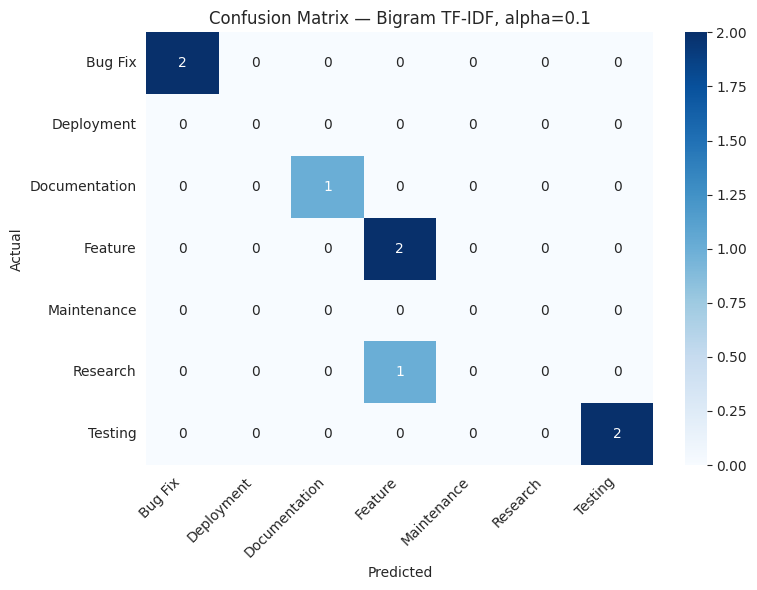

In [8]:
best_name, best_model, best_Xte, best_preds = (
    ("Bigram", grid_bi.best_estimator_, Xte_bi, preds_bi)
    if report_bi["macro avg"]["f1-score"] >= report_uni["macro avg"]["f1-score"]
    else ("Unigram", grid_uni.best_estimator_, Xte_uni, preds_uni)
)
print(f"Best feature set by macro-F1: {best_name}")

labels = sorted(y.unique())
cm = confusion_matrix(y_test, best_preds, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, cbar=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_name} TF-IDF, alpha={best_model.alpha}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Observations

*(Auto-drafted from the current run's numbers below — rewrite this section once the full dataset results are in; the sample is too small for the confusion patterns to be meaningful.)*

In [9]:
# Helper: find which categories get confused with which
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
print("Confusion matrix:\n", cm_df)

print("\nOff-diagonal confusions (Actual -> Predicted, count):")
for actual in labels:
    for predicted in labels:
        if actual != predicted and cm_df.loc[actual, predicted] > 0:
            print(f"  {actual} -> {predicted}: {cm_df.loc[actual, predicted]}")

research_recall = report_bi.get("Research", report_uni.get("Research", {})).get("recall", None)
if research_recall is not None:
    print(f"\nResearch class recall (best model): {research_recall:.2f}")

Confusion matrix:
                Bug Fix  Deployment  Documentation  Feature  Maintenance  \
Bug Fix              2           0              0        0            0   
Deployment           0           0              0        0            0   
Documentation        0           0              1        0            0   
Feature              0           0              0        2            0   
Maintenance          0           0              0        0            0   
Research             0           0              0        1            0   
Testing              0           0              0        0            0   

               Research  Testing  
Bug Fix               0        0  
Deployment            0        0  
Documentation         0        0  
Feature               0        0  
Maintenance           0        0  
Research              0        0  
Testing               0        2  

Off-diagonal confusions (Actual -> Predicted, count):
  Research -> Feature: 1

Research class reca

**Notes to fill in once run on the full dataset:**

- Which categories are most often confused with each other, and do they share vocabulary (e.g., "Testing" vs "Bug Fix" both mention "test", "fix", "error")?
- Does `Research` get absorbed into a larger class? If so, which one, and why (shared words like "analyze", "review", "report")?
- Did bigrams help or hurt macro-F1 relative to unigrams? Bigrams can capture domain phrases ("load testing", "role based access") but can also fragment the already-small `Research`/`Documentation`/`Deployment` classes further by making the feature space sparser.
- What alpha won for each feature set, and does a higher alpha (more smoothing) help small classes at the cost of large-class precision?
